# Visión por Computador - Práctica 2 - Deep Learning en Computer Vision

#### 15 puntos   |   Fecha de entrega: 7 de Diciembre, 23:59   |   Forma de entrega: a través de la tarea creada en https://pradogrado2526.ugr.es/

### Estudiante: <mark>Jaime Corzo Galdó</mark>

## Normas de desarrollo y entrega de la práctica

1. Para este trabajo, al igual que para los demás, se debe presentar código, resultados, discusión de los mismos, y presentación y análisis del trabajo realizado, todo integrado en el propio Google Colab Notebook (es decir, no se entrega ninguna memoria separada en `.pdf` ni ningún código `.py`). Se recuerda que código y resultados sin informe explicativo no puntúa. Resulta también fundamental recordar que solo se acepta la entrega de ficheros `.ipynb` (no resulta válido entregar un fichero `.py`).

2. En relación con el punto anterior, se recuerda que se proporciona un Notebook, denominado `Ejemplo_Otsu.ipynb`, que muestra un ejemplo de respuesta y solución a un potencial ejercicio. El propósito de este Notebook es servir de referencia al alumnado acerca de cómo responder los ejercicios planteados. Véase que, por ejemplo, en aras de diferenciar con facilidad enunciados y respuestas, estas últimas se presentan en otro color (azul, en ese caso).

3. El diseño de celdas del documento debe ser respetado. Es decir, no se puede modificar el orden de los ejercicios o alterar la estructura del Notebook, de forma que dificulte localizar los contenidos. Aunque sí se puede, por ejemplo, crear nuevas subsecciones dentro de las secciones ya existentes para estructurar y organizar con más claridad las respuestas, así como para incluir los experimentos extra que se deseen.

4. Tal y como se muestra en `Ejemplo_Otsu.ipynb`, no hay ningún problema en emplear técnicas de IA generativa (como ChatGPT o Gemini) para crear el código de los distintos ejercicios o para enriquecer el análisis y descripción del trabajo realizado (aunque, obvia decirlo, su uso no es obligatorio). Pero, en caso de usarse, sí se debe aclarar de qué modo se ha usado la IA, con qué objetivo, y se debe demostrar que se entiende perfectamente lo que se ha hecho.

5. Solo se entregará el fichero `.ipynb` (incorporando código, resultados, y explicación del trabajo realizado y los resultados obtenidos) y no se enviarán las imágenes empleadas. El path para la lectura de imágenes, o cualquier otro fichero de entrada, debe ser siempre “/content/drive/My Drive/images/nombre_fichero”.

6. El código deberá  presentarse adecuadamente comentado y con los resultados obtenidos en cada apartado, junto con la presentación del trabajo realizado y la discusión y análisis de los resultados obtenidos. Es importante reiterar que la entrega de código sin informe explicativo o valoraciones no puntúa. Por otro lado, el código debe ir comentado en comentarios en celdas de código, mientras que el análisis y discusión, tanto del trabajo realizado como de los resultados obtenidos, debe ir en celdas de texto.






### Materiales de Apoyo

En caso de que el alumnado tenga dudas sobre Python, OpenCV o el uso de Google Colab, se recuerda que en PRADO hay materiales de apoyo (https://pradogrado2526.ugr.es/mod/folder/view.php?id=95307):
-  Introducción a Python: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/1.%20Introduccion%20a%20Python.pdf
- Introducción a NumPy, Matplotlib y Scikit-learn: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/2.%20Introducción%20a%20Numpy%20Matplotlib%20y%20sklearn.pdf
- Notebook con toda la información anterior (y más cosas): https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Guia_Python.ipynb
- Ejercicios y ejemplos de repaso: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/3.%20Ejercicios%20y%20ejemplos%20de%20repaso.pdf
- Fundamentos de Python para lectura, visualización y manipulación de imágenes: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/4.%20Fundamentos%20de%20Python%20para%20manipulacion%20de%20imagenes.pdf (y Notebook asociado: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Guia_fundamentos_imagenes.ipynb)
- Ideas sobre cómo redactar un documento académico-científico (útil para saber cómo documentar las respuestas a los ejercicios, el Notebook en su conjunto, y la memoria del proyecto final o de un TFG/TFM): https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Algunas%20ideas%20sobre%20cómo%20elaborar%20un%20informe%20académico-científico.pdf
- Ejemplo de respuesta a un hipotético ejercicio sobre el algoritmo de umbralización de Otsu: https://pradogrado2526.ugr.es/pluginfile.php/243164/mod_folder/content/0/Ejemplo_Otsu.ipynb

In [ ]:
# The first thing we should do is to apply hardware acceleration via GPU. So, we have to go to Editar - Configuracion del Cuaderno - Acelerador por Hardware GPU

# Now we SET UP Fastai
!pip install -Uqq fastbook
!pip install nbdev
import fastbook
fastbook.setup_book()
import fastai
import fastcore
print(f'fastcore version {fastcore.__version__} installed')
print(f'fastai version {fastai.__version__} installed')
from nbdev.showdoc import *
from fastai.vision.all import *

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 5.2 MB/s eta 0:00:00
Mounted at /content/gdrive
fastcore version 1.9.2 installed
fastai version 2.8.6 installed


In [ ]:
# Function to display evaluation metrics

@patch
@delegates(subplots)
def plot_metrics(self: Recorder, nrows=None, ncols=None, figsize=None, **kwargs):
    metrics = np.stack(self.values)
    names = self.metric_names[1:-1]
    n = len(names) - 1
    if nrows is None and ncols is None:
        nrows = int(math.sqrt(n))
        ncols = int(np.ceil(n / nrows))
    elif nrows is None: nrows = int(np.ceil(n / ncols))
    elif ncols is None: ncols = int(np.ceil(n / nrows))
    figsize = figsize or (ncols * 6, nrows * 4)
    fig, axs = subplots(nrows, ncols, figsize=figsize, **kwargs)
    axs = [ax if i < n else ax.set_axis_off() for i, ax in enumerate(axs.flatten())][:n]
    for i, (name, ax) in enumerate(zip(names, [axs[0]] + axs)):
        ax.plot(metrics[:, i], color='#1f77b4' if i == 0 else '#ff7f0e', label='valid' if i > 0 else 'train')
        ax.set_title(name if i > 1 else 'losses')
        ax.legend(loc='best')
    plt.show()



---



---



---



# **Ejercicio 4: Primeros pasos de IA explicable aplicada a redes neuronales convolucionales (2 puntos)**
En este ejercicio trabajaremos con el conjunto de datos Caltech-UCSD Birds-200-2011 (https://www.vision.caltech.edu/datasets/cub_200_2011/). Este conjunto de datos consta de $11788$ imágenes de $200$ especies de aves diferentes. Tiene $200$ clases, con $5994$ para entrenamiento y $5794$ para pruebas. El $10\%$ del conjunto de entrenamiento se dejará para validación.

Usaremos el modelo de red EfficientNet-B0 ya preentrenado con ImageNet. Se realizará un fine-tuning de toda la red ($1$ época la cabecera y $10$ épocas toda la red) tras haber incorporado una cabecera adecuada para este problema (con global average pooling y una única fully-connected layer).





In [ ]:
# https://docs.fast.ai/data.external.html
path = untar_data(URLs.CUB_200_2011)

In [ ]:
print(path)
print(path.ls())
print((path/'CUB_200_2011/').ls())
train_test_split = np.loadtxt('/root/.fastai/data/CUB_200_2011/CUB_200_2011/train_test_split.txt',dtype=int)
# !cat /root/.fastai/data/CUB_200_2011/CUB_200_2011/train_test_split.txt

print('Number of testing examples: ', (train_test_split[:,1]== 0).sum())
print('Number of training examples: ', (train_test_split[:,1]== 1).sum())
print(train_test_split)


/root/.fastai/data/CUB_200_2011
[Path('/root/.fastai/data/CUB_200_2011/CUB_200_2011'), Path('/root/.fastai/data/CUB_200_2011/attributes.txt')]
[Path('/root/.fastai/data/CUB_200_2011/CUB_200_2011/train_test_split.txt'), Path('/root/.fastai/data/CUB_200_2011/CUB_200_2011/attributes'), Path('/root/.fastai/data/CUB_200_2011/CUB_200_2011/classes.txt'), Path('/root/.fastai/data/CUB_200_2011/CUB_200_2011/images'), Path('/root/.fastai/data/CUB_200_2011/CUB_200_2011/parts'), Path('/root/.fastai/data/CUB_200_2011/CUB_200_2011/README'), Path('/root/.fastai/data/CUB_200_2011/CUB_200_2011/images.txt'), Path('/root/.fastai/data/CUB_200_2011/CUB_200_2011/bounding_boxes.txt'), Path('/root/.fastai/data/CUB_200_2011/CUB_200_2011/image_class_labels.txt')]
Number of testing examples:  5794
Number of training examples:  5994
[[    1     0]
 [    2     1]
 [    3     0]
 ...
 [11786     0]
 [11787     1]
 [11788     0]]


In [ ]:
with open('/root/.fastai/data/CUB_200_2011/CUB_200_2011/images.txt') as file:
    images_list = file.readlines()
    images_list = [line.rstrip() for line in images_list]
print(images_list)

['1 001.Black_footed_Albatross/Black_Footed_Albatross_0046_18.jpg', '2 001.Black_footed_Albatross/Black_Footed_Albatross_0009_34.jpg', '3 001.Black_footed_Albatross/Black_Footed_Albatross_0002_55.jpg', '4 001.Black_footed_Albatross/Black_Footed_Albatross_0074_59.jpg', '5 001.Black_footed_Albatross/Black_Footed_Albatross_0014_89.jpg', '6 001.Black_footed_Albatross/Black_Footed_Albatross_0085_92.jpg', '7 001.Black_footed_Albatross/Black_Footed_Albatross_0031_100.jpg', '8 001.Black_footed_Albatross/Black_Footed_Albatross_0051_796103.jpg', '9 001.Black_footed_Albatross/Black_Footed_Albatross_0010_796097.jpg', '10 001.Black_footed_Albatross/Black_Footed_Albatross_0025_796057.jpg', '11 001.Black_footed_Albatross/Black_Footed_Albatross_0023_796059.jpg', '12 001.Black_footed_Albatross/Black_Footed_Albatross_0086_796062.jpg', '13 001.Black_footed_Albatross/Black_Footed_Albatross_0049_796063.jpg', '14 001.Black_footed_Albatross/Black_Footed_Albatross_0006_796065.jpg', '15 001.Black_footed_Albatr

In [ ]:
classes = (path/'CUB_200_2011/images/').ls()
print('Number of examples per class')
for i in range(len(classes)):
  print(len(classes[i].ls()), end=" ")


Number of examples per class
60 60 60 60 59 60 59 60 59 60 44 59 60 53 60 60 48 60 60 60 60 60 60 60 59 59 60 60 60 60 60 60 60 60 41 59 60 60 60 60 50 59 53 60 60 59 50 60 60 58 60 60 60 60 60 49 60 60 60 60 57 59 60 60 60 50 60 60 58 60 60 60 51 60 60 60 60 60 58 60 59 60 60 59 59 60 60 59 56 60 60 60 60 60 60 59 45 60 59 59 59 60 60 60 60 60 60 50 60 60 60 60 60 60 60 60 60 53 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 59 60 60 57 60 60 60 60 60 60 60 60 60 60 56 60 59 59 60 60 60 60 60 59 60 60 60 60 58 59 59 60 60 60 59 58 52 59 60 59 60 59 60 60 60 59 60 60 60 60 56 59 60 60 60 60 60 60 60 58 59 60 60 60 

In [ ]:
#Ahora tenemos en images_list la lista con todas las imágenes, y en train_test_split cuáles pertenecen a training (1) o a test (0)
# Vamos a crear dos carpetas: una train y otra test, y vamos a meter dentro las imágenes correspondientes
print(path)
import shutil, os
if os.path.isdir('/root/.fastai/data/CUB_200_2011/train'):
  shutil.rmtree('/root/.fastai/data/CUB_200_2011/train')
if os.path.isdir('/root/.fastai/data/CUB_200_2011/test'):
  shutil.rmtree('/root/.fastai/data/CUB_200_2011/test')

shutil.copytree('/root/.fastai/data/CUB_200_2011/CUB_200_2011/images','/root/.fastai/data/CUB_200_2011/train')
shutil.copytree('/root/.fastai/data/CUB_200_2011/CUB_200_2011/images','/root/.fastai/data/CUB_200_2011/test')


/root/.fastai/data/CUB_200_2011


'/root/.fastai/data/CUB_200_2011/test'

In [ ]:
print((path/'train').ls())
print(len((path/'train').ls()))

[Path('/root/.fastai/data/CUB_200_2011/train/122.Harris_Sparrow'), Path('/root/.fastai/data/CUB_200_2011/train/194.Cactus_Wren'), Path('/root/.fastai/data/CUB_200_2011/train/072.Pomarine_Jaeger'), Path('/root/.fastai/data/CUB_200_2011/train/114.Black_throated_Sparrow'), Path('/root/.fastai/data/CUB_200_2011/train/019.Gray_Catbird'), Path('/root/.fastai/data/CUB_200_2011/train/145.Elegant_Tern'), Path('/root/.fastai/data/CUB_200_2011/train/037.Acadian_Flycatcher'), Path('/root/.fastai/data/CUB_200_2011/train/001.Black_footed_Albatross'), Path('/root/.fastai/data/CUB_200_2011/train/179.Tennessee_Warbler'), Path('/root/.fastai/data/CUB_200_2011/train/165.Chestnut_sided_Warbler'), Path('/root/.fastai/data/CUB_200_2011/train/005.Crested_Auklet'), Path('/root/.fastai/data/CUB_200_2011/train/160.Black_throated_Blue_Warbler'), Path('/root/.fastai/data/CUB_200_2011/train/069.Rufous_Hummingbird'), Path('/root/.fastai/data/CUB_200_2011/train/084.Red_legged_Kittiwake'), Path('/root/.fastai/data/CU

In [ ]:
import os
for i in range(len(train_test_split)):
    if train_test_split[i,1]==0: #test image
       os.remove(path/'train'/images_list[i].rsplit(' ')[1]) #we remove it from train
    if train_test_split[i,1]==1: #train image
      os.remove(path/'test'/images_list[i].rsplit(' ')[1]) #we remove it from test

In [ ]:
files_train = get_image_files(path/'train')
files_test = get_image_files(path/'test')
print('Total training images: ', len(files_train))
print('Total test images: ', len(files_test))


Total training images:  5994
Total test images:  5794


## Implementación, entrenamiento y validación del modelo (0.5 pts).

Numero de ejemplos de entrenamiento (una vez descartados los de validacion): 5395
Numero de ejemplos de validacion: 599


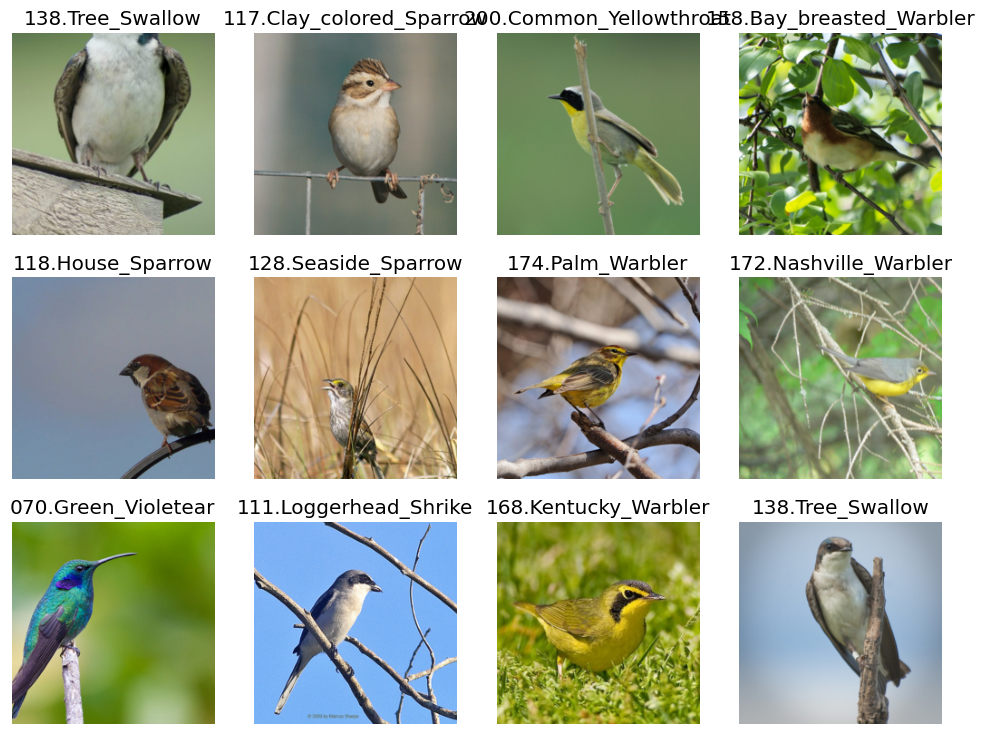

In [ ]:
# DataBlock para CUB_200_2011
# - ImageBlock: imágenes
# - CategoryBlock: 200 especies de aves
# - 10% del train se usa como valid
# - Redimensionamos todas las imágenes a 224x224
# - Normalizamos con estadísticos de ImageNet para usar EfficientNet-B0 preentrenada
CUB_200_2011 = DataBlock(
    # A CUBRIR POR EL ALUMNADO
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.1, seed=42), #10% of the training set will be used for validation
    get_y=parent_label,
    item_tfms=Resize(224),                            # todas las imágenes al mismo tamaño
    batch_tfms=[Normalize.from_stats(*imagenet_stats)]
)

dls = CUB_200_2011.dataloaders(path/'train',batch_size=64)

dls.show_batch(max_n=12)

print('Numero de ejemplos de entrenamiento (una vez descartados los de validacion):', len(dls.train_ds))
print('Numero de ejemplos de validacion:', len(dls.valid_ds))

<font color='blue'>Según he visto en internet, la arquitectura EfficientNet-B0, que sirve como el modelo base de toda la familia EfficientNet, sigue este flujo:

1. <font color='blue'>Capa convolucional inicial
Una conv 3x3 con stride 2 que reduce la resolución e introduce los primeros canales.

2. <font color='blue'>Varias etapas de MBConv
Cada etapa tiene distintos:
   -  <font color='blue'>tamaños de kernel,
   - anchos de canal,
   - números de repeticiones,
   - y, en algunas etapas, downsampling para disminuir la resolución mientras aumenta la profundidad del modelo.

3. <font color='blue'>Capa final expandida
Una convolución 1x1 que expande las características a 1280 canales, seguida de:
    - <font color='blue'>batch normalization,
    - activación Swish.

4. <font color='blue'>Global Average Pooling
Que reduce cada mapa de características a un único valor, resumiendo la información aprendida.

5. <font color='blue'>Clasificador final
Una capa densa completamente conectada con softmax, que produce las probabilidades de clase.

<font color='blue'>Además, EfficientNet-B0 es un modelo preentrenado en el conjunto de datos ImageNet, que contiene más de un millón de imágenes y 1000 clases. Pero nosotros vamos a modificar la cabecera para adaptarla a nuestro data set y posteriormente vamos a realizar un fine tuning entrenando toda la red con un learning rate menor.

<font color='blue'>Ahora tenemos que aprovechar las capas convolucionales quen han aprendido a ver bordes, texturas, formas... pero modificando la capa final. Quitamos el Global Average Pooling y el clasificador final y pasamos de [batch, 1280, 7, 7] a un vector de tamaño $512*1*1 = 1280$ después de aplicar AdaptiveAvgPool2d y Linear, al final tendremos 200 neuronas, una para cada clase.

<font color='blue'>Para ello vamos a usar la función vision_learner para crear el learner (en fastai, cnn_learner es básicamente el nombre antiguo y está marcado como deprecated, así que conviene usar directamente vision_learner). Está pensado para construir un learner a partir de un objeto data loader (dls) y una arquitectura de modelo específica (arch). Algunos de los argumentos clave que acepta incluyen:

- <font color='blue'>dls: el data loader que proporciona los datos de entrenamiento y validación.

- <font color='blue'>arch: la arquitectura del modelo, como resnet18, resnet34 o resnet50.

- <font color='blue'>normalize: si es True, puede añadir automáticamente la normalización adecuada cuando se hace transfer learning con pesos preentrenados.

- <font color='blue'>n_out: número de salidas (en regresión de edad normalmente será 1, es decir, un único valor).

- <font color='blue'>pretrained: si usar o no pesos preentrenados (por ejemplo, de ImageNet).

- <font color='blue'>weights: permite elegir qué pesos preentrenados usar (si aplica).

- <font color='blue'>metrics: métricas opcionales para evaluar el desempeño.

- <font color='blue'>loss_func: función de pérdida personalizada.

- <font color='blue'>opt_func: función de optimización.

- <font color='blue'>lr: tasa de aprendizaje.

- <font color='blue'>wd: weight decay.

- <font color='blue'>cbs: callbacks a usar durante el entrenamiento.

<font color='blue'>La función vision_learner puede personalizarse especificando parámetros como:

- <font color='blue'>cut: define dónde se corta el modelo para separar el body del head.

- <font color='blue'>custom_head: permite definir una cabeza personalizada en lugar de la predeterminada.

<font color='blue'>Como función de pérdida vamos a usar la predeterminada para problemas de clasificación en fastai,  que es el CrossEntropyLossFlat(). Además, como métrica vamos a usar accuracy.

<font color='blue'>Accuracy es una métrica utilizada para evaluar el rendimiento de un modelo de clasificación, midiendo la proporción de predicciones correctas realizadas por el modelo sobre un conjunto de datos.

<font color='blue'>Se calcula como el cociente entre el número de instancias correctamente predichas y el número total de instancias.

In [ ]:
# A CUBRIR POR EL ALUMNADO
# Número de clases
n_classes = dls.c

NF = 1280  # canales de salida de EfficientNet-B0 antes de la cabecera original

# Definimos la cabecera
my_eff_head = nn.Sequential(
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(NF, n_classes)
)

# Creamos el learner con EfficientNet-B0 preentrenada
learn_eff = vision_learner(
    dls,
    efficientnet_b0,
    pretrained=True,
    cut=-2,
    custom_head=my_eff_head,
    loss_func=CrossEntropyLossFlat(),
    metrics=[accuracy]
)

# Fase 1: solo cabecera (1 época)
learn_eff.freeze()

learn_eff.summary()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 118MB/s] 


Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 32 x 112 x 112 
Conv2d                                    864        False     
BatchNorm2d                               64         True      
SiLU                                                           
Conv2d                                    288        False     
BatchNorm2d                               64         True      
SiLU                                                           
____________________________________________________________________________
                     64 x 32 x 1 x 1     
AdaptiveAvgPool2d                                              
____________________________________________________________________________
                     64 x 8 x 1 x 1      
Conv2d                                    264        False     
____________________________________________________________________________
                     6

SuggestedLRs(valley=0.0012022644514217973)

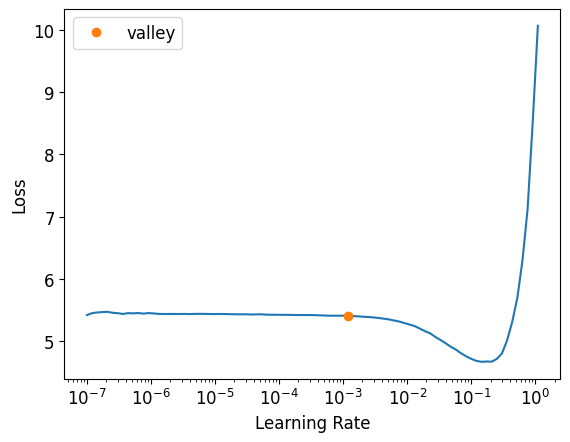

In [ ]:
learn_eff.lr_find()

In [ ]:
learn_eff.fit(1, 0.0036)

epoch,train_loss,valid_loss,accuracy,time
0,2.835091,1.699680,0.542571,00:44


<font color='blue'>Escogemos como learning rate cuando la pérdida empieza a bajar rápido, y antes de que se dispare hacia arriba.

In [ ]:
# Fase 2: todo (10 épocas)
learn_eff.unfreeze()

learn_eff.summary()

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 32 x 112 x 112 
Conv2d                                    864        True      
BatchNorm2d                               64         True      
SiLU                                                           
Conv2d                                    288        True      
BatchNorm2d                               64         True      
SiLU                                                           
____________________________________________________________________________
                     64 x 32 x 1 x 1     
AdaptiveAvgPool2d                                              
____________________________________________________________________________
                     64 x 8 x 1 x 1      
Conv2d                                    264        True      
____________________________________________________________________________
                     6

SuggestedLRs(valley=0.0002754228771664202)

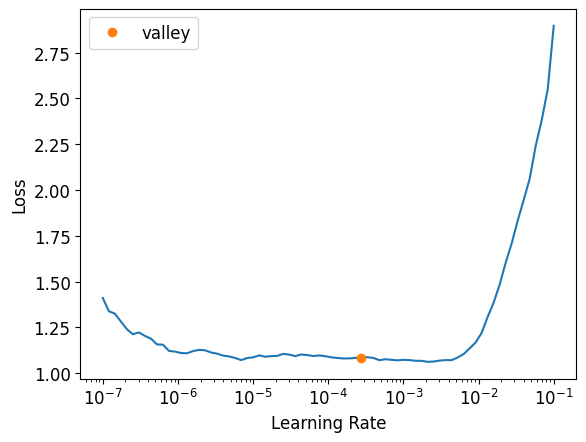

In [ ]:
learn_eff.lr_find()

In [ ]:
learn_eff.fit(10, 0.00019)

epoch,train_loss,valid_loss,accuracy,time
0,0.874120,1.230092,0.657763,00:53
1,0.507779,1.130022,0.684474,00:35
2,0.304404,1.135274,0.687813,00:37
3,0.194417,1.082765,0.697830,00:39
4,0.126016,1.072721,0.716194,00:36
5,0.085968,1.066879,0.717863,00:38
6,0.063580,1.074304,0.707846,00:35
7,0.052652,1.094126,0.709516,00:37
8,0.038998,1.078084,0.704508,00:41
9,0.032690,1.113786,0.709516,00:48


Train  - loss 0.0080  acc 0.9994
Valid  - loss 1.1138  acc 0.7095
Test   - loss 0.9911  acc 0.7447


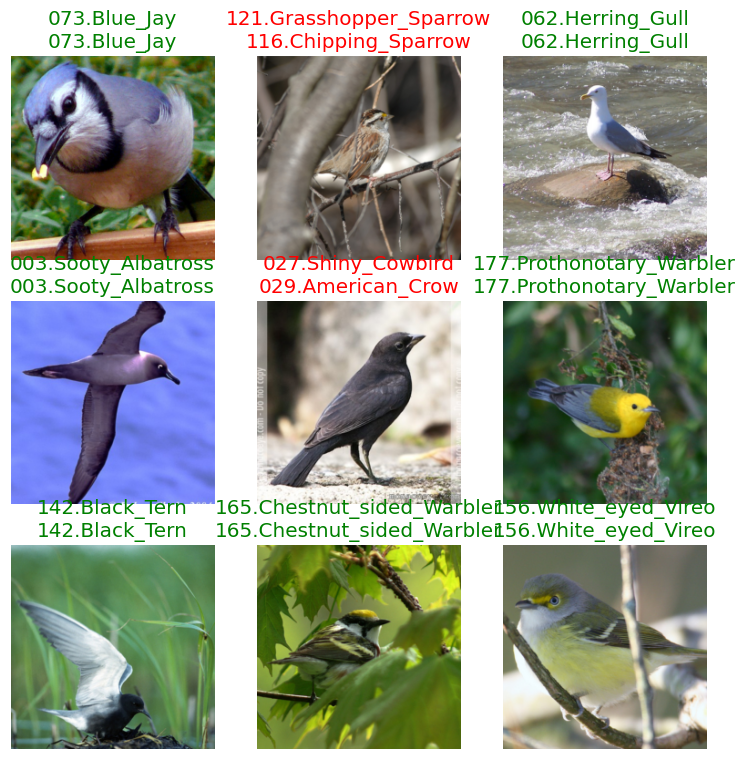

In [ ]:
learn_eff.show_results()

test_dl = dls.test_dl(files_test, with_labels=True)

# Evaluación en train, valid, test
loss_tr, acc_tr = learn_eff.validate(dl=dls.train)
loss_va, acc_va = learn_eff.validate(dl=dls.valid)
loss_te, acc_te = learn_eff.validate(dl=test_dl)

print(f"Train  - loss {loss_tr:.4f}  acc {acc_tr:.4f}")
print(f"Valid  - loss {loss_va:.4f}  acc {acc_va:.4f}")
print(f"Test   - loss {loss_te:.4f}  acc {acc_te:.4f}")


<font color='blue'>**Evaluación del rendimiento**

<font color='blue'>En el experimento con EfficientNet-B0 preentrenada en ImageNet, tras realizar un fine-tuning de la red (primero entrenando solo la cabecera y después toda la red), se obtienen unos resultados de entrenamiento prácticamente perfectos (loss muy baja y accuracy del 100%), lo que indica que el modelo tiene capacidad suficiente para ajustar por completo el conjunto de entrenamiento. Este comportamiento es esperable en una arquitectura potente como EfficientNet-B0 aplicada a un dataset de tamaño moderado como Caltech-UCSD Birds-200-2011.

<font color='blue'>En el conjunto de validación, la loss aumenta hasta aproximadamente 1.15 y la accuracy se sitúa en torno al 73%. En el conjunto de test, la loss baja ligeramente respecto a validación hasta unos 0.96 y la accuracy sube hasta alrededor del 75%. Esto sugiere que el modelo generaliza razonablemente bien, ya que mantiene una tasa de acierto elevada en datos no vistos, teniendo en cuenta además que se trata de un problema de clasificación con 200 clases, donde acertar al azar tendría una probabilidad de solo un 0.5%.

<font color='blue'>En conjunto, los resultados indican que el fine-tuning de EfficientNet-B0 sobre el conjunto Caltech-UCSD Birds-200-2011 es efectivo: el modelo permite distinguir entre un gran número de especies de aves con una precisión elevada. Al mismo tiempo, el gap entre entrenamiento (100% de acierto) y validación/test (alrededor del 73-75%) pone de manifiesto cierto grado de sobreajuste, algo esperable en este tipo de problema, pero que no impide que el rendimiento en test bastante aceptable.

##  Uso de Grad-CAM para analizar el comportamiento de redes convolucionales (1 pto)

 Una vez entrenado el modelo, se debe aplicar Grad-CAM para visualizar los mapas de activación del **último bloque convolucional** (y solo de este último bloque). Es importante que el alumnado demuestre y explique que, efectivamente, está aplicando Grad-CAM sobre el último bloque convolucional.

 Para ello, los alumnos deben emplear el paquete `grad-cam`: `!pip install grad-cam`. Se trata de una librería con métodos del estado del arte para dotar de explicabilidad a modelos de visión por computador. Se recomienda encarecidamente revisar con calma la documentación relativa a dicho paquete (https://jacobgil.github.io/pytorch-gradcam-book/introduction.html y https://github.com/jacobgil/pytorch-grad-cam) y basarse en los ejemplos allí indicados de cara a realizar la implementación. El alumnado debe emplear Grad-CAM con, al menos, $5$ imágenes de test, así como interpretar los resultados obtenidos.  

 ¿En qué consiste Grad-CAM: cómo funciona y para qué sirve?

 Referencia: https://arxiv.org/pdf/1610.02391.pdf

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 106.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=80f42528bfea4a0debebeeb14580e28d855a76dfd439c42ddf4bf38ac3bdd52b
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


<font color='blue'>Para realizar este ejercicio he usado parte del codigo de pytorch-grad-cam/cam.py y para obtener las capas convolucionales he pedido ayuda al ChatGpt, ya que el modelo que he usado se crea de una manera diferente usando el vision_learner.

<font color='blue'>En primer lugar definimos los diferentes métodos de GradCam que podemos usar como un diccionario, aunque el por defecto va a ser "gradcam". Estos métodos luego se van a poder pasar como atributo a una función al crear el objeto cam.

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from fastai.vision.all import *
from pytorch_grad_cam import (
    GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus,
    AblationCAM, XGradCAM, EigenCAM, EigenGradCAM,
    LayerCAM, FullGrad
)
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Diccionario de métodos
cam_methods = {
    "gradcam": GradCAM,
    "hirescam": HiResCAM,
    "scorecam": ScoreCAM,
    "gradcam++": GradCAMPlusPlus,
    "ablationcam": AblationCAM,
    "xgradcam": XGradCAM,
    "eigencam": EigenCAM,
    "eigengradcam": EigenGradCAM,
    "layercam": LayerCAM,
    "fullgrad": FullGrad,
}

<font color='blue'>Ahora **extraemos el útimo bloque convolucional**, que es la que nos piden en el ejercicio, y lo guardamos en target_layer, que es un parámetro que se le pasa al objeto cam en su creación, para indicarle al Cam de que capas tiene que computar la visualización. Recordamos que el modelo es learn_eff.model que lo podemos ver como:

<font color='blue'>*Sequential(*

<font color='blue'>  *[0] = body (EfficientNet-B0 sin cabecera original)*

 <font color='blue'> *[1] = my_eff_head (GAP + Linear)*

<font color='blue'>*)*

<font color='blue'>Para ver cual es el último bloque convolucional, hacemos un print del modelo. El código *model = learn_eff.model.eval()* pone el modelo en modo de evaluación, lo que desactiva las capas de dropout y hace que las capas de batch normalization utilicen las estadísticas acumuladas durante el entrenamiento en lugar de las estadísticas del lote actual.

<font color='blue'>Esto garantiza un comportamiento consistente durante la inferencia, lo cual es crucial para una evaluación precisa.

<font color='blue'>Luego, la instrucción *print(model)* mostrará la representación en forma de texto del modelo (es decir, su arquitectura)

<font color='blue'>En ella podemos ver en primer lugar que en la posición [0] como hemos comentado se encuentran todo el cuerpo de la EfficientNet-B0 original y posteriormente tenemos lacabacera que hemos añadido.

<font color='blue'>Lo único que tenemos que hacer es tomar el último bloque convolucional, que sería el [0][0][8]. Este bloque incluye la capa convolucional, la de BatchNormalization y la función de activación. Si me gustariá comentar que este bloque se puede entender como un **bloque convolucional "simple"** y los MBConv (el bloque principal de EfficientNet: expansión, depthwise, SE, proyección, etc.) como un **bloque convolucional “complejo”**. Un ejemplo sería si cogiesemos model[0][0][7][0].

<font color='blue'>Sin embargo, hemos optado por coger el último ya que sigue teniendo una capa convolucional y de hecho es muy habitual usar la “última convolucional” antes del pooling.

In [ ]:
model = learn_eff.model.eval()

#Nos quedamos con la parte convolucional de EfficientNet-B0
print(model)

print("\nUltimo Bloque Convolucional:\n")
print(model[0][0][8])


Sequential(
  (0): Sequential(
    (0): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale_activation): Sigm

<font color='blue'>Creamos ahora el objeto cam, se le pasa el modelo, que en nuestro caso es el que está formado por el cuerpo preentrenado de EfficientNet_B0 y la cabecera que le hemos añadido, más el target layer obtenido previamente.

In [ ]:
target_layer = model[0][0][8]
def make_cam(method_name="gradcam"):
    cam_class = cam_methods[method_name]
    cam = cam_class(
        model=model,
        target_layers=[target_layer]
    )
    return cam


<font color='blue'>Ahora por simplificar la resolución del ejercicio, creamos una función que recibe una imagen y un método de gradcam(que posteriormente se pasará a la función make_cam) y que muestra por pantalla tanto la imagen como la imagen superpuesta con el heatmap que genera GradCam.

<font color='blue'>Siguiendo el código de ejemplo del git, primero obtenemos la imagen a color usando el path que se pasa como argumento y obtenemos el tensor de la imagen. Esto lo hemos hecho un poco distinto para aprovechar que ya tenemos creado el DataLoader, que tiene toda la información que necesitamos ya que es el DataLoaders del entrenamiento, con item_tfms, Resize, Normalize... Luego lo que hacemos es crear un DataLoader de "test" a partir de *img_path* aplicando las mismas transformaciones que se usaron para el entrenamiento.

<font color='blue'>Posteriormente llamamos a a función make_cam para crear el objeto cam y tenemos que especificar el target para el que queremos generar la Class Activation Maps. Si indicamos que sea None, la categoría con la puntuación más alta (para cada elemento del batch) será la que se utilice.

<font color='blue'>Ahora solo tenemos que redimensionar la imagen para adaptarla al tamaño de las imagenes con las que estamos trabajando y superponer el mapa de calor que ha generado cam, que hemos guardado en grayscale_cam, con la imagen original.

<font color='blue'>aug_smooth=True y eigen_smooth=True sirven para aplicar suavizado.

In [ ]:
import matplotlib.pyplot as plt
import cv2

def run_cam_on_image(img_path, method_name="gradcam"):
    # 1) Cargar imagen
    rgb_img = cv2.imread(img_path, 1)[:, :, ::-1]
    rgb_img = np.float32(rgb_img) / 255

    dl = dls.test_dl([img_path], with_labels=False)
    x, = first(dl)              # x: tensor normalizado [1,3,H,W]

    # 2) Constrimos el objeto cam
    cam = make_cam(method_name)

    # 3) Target: None -> usa la clase con mayor score
    targets = None

    # 4) Ejecutamos CAM
    grayscale_cam = cam(
        input_tensor=x,
        targets=targets,
        aug_smooth=True,
        eigen_smooth=True
    )

    grayscale_cam = grayscale_cam[0, :]

    # 5) Redimensionar la imagen al tamaño del CAM
    h, w = grayscale_cam.shape
    rgb_resized = cv2.resize(rgb_img, (w, h))  # ahora (224,224,3)

    # 6) Superponer heatmap
    cam_image = show_cam_on_image(rgb_resized, grayscale_cam, use_rgb=True)

    # 7) Mostrar
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.title("Imagen original")
    plt.imshow(rgb_img)
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title(f"{method_name} (ultima capa conv)")
    plt.imshow(cam_image)
    plt.axis('off')
    plt.show()


/root/.fastai/data/CUB_200_2011/test/122.Harris_Sparrow/Harris_Sparrow_0075_116404.jpg


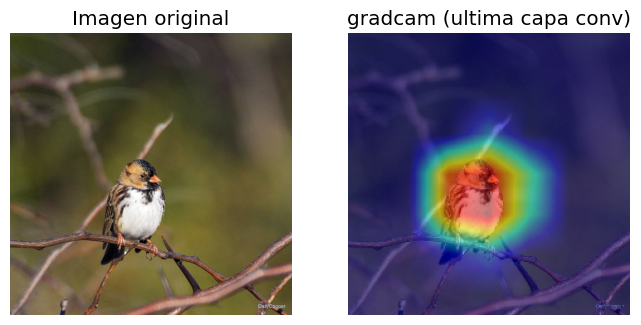

/root/.fastai/data/CUB_200_2011/test/122.Harris_Sparrow/Harris_Sparrow_0004_116581.jpg


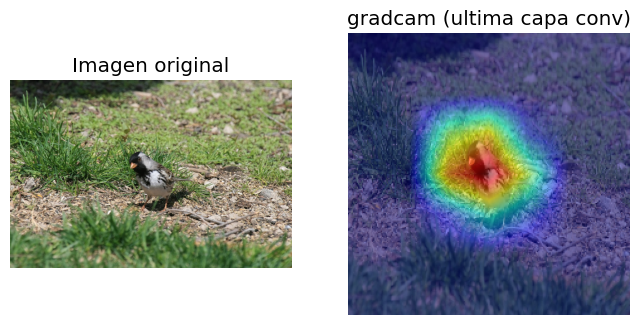

/root/.fastai/data/CUB_200_2011/test/122.Harris_Sparrow/Harris_Sparrow_0085_116534.jpg


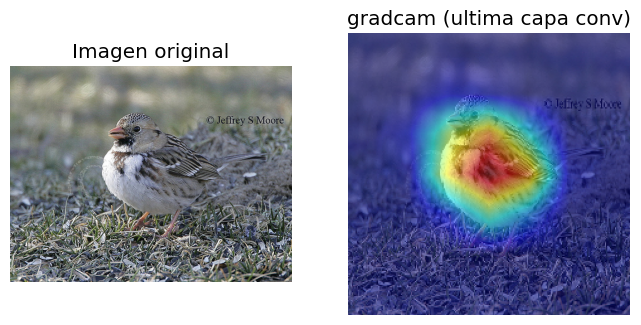

/root/.fastai/data/CUB_200_2011/test/122.Harris_Sparrow/Harris_Sparrow_0045_116603.jpg


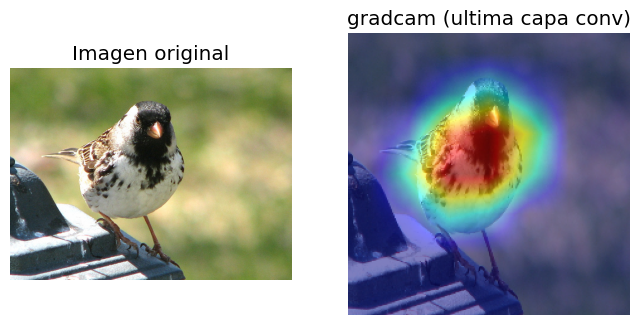

/root/.fastai/data/CUB_200_2011/test/122.Harris_Sparrow/Harris_Sparrow_0083_116588.jpg


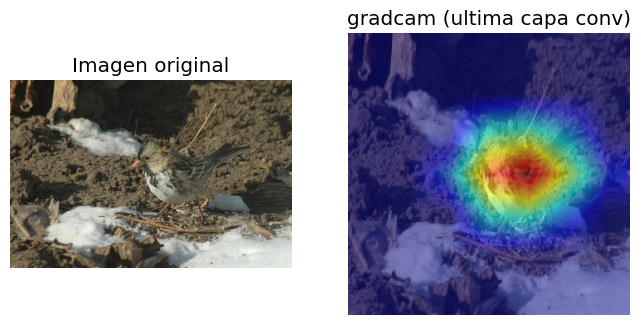

In [ ]:
# Usamos las primeras 5 imágenes del conjunto de test
sample_paths = files_test[:5]

for p in sample_paths:
    print(p)
    run_cam_on_image(p, method_name="gradcam")

<font color='blue'>**Análisis de resultados**

<font color='blue'>Para realizarlo vamos a empezar dando una explicación que que hace GradCam y como funciona, con lo que damos respuesta a la pregunta **¿En qué consiste Grad-CAM: cómo funciona y para qué sirve?** tomando como referencia el artículo *https://arxiv.org/pdf/1610.02391*.

<font color='blue'>**Grad-CAM (Gradient-weighted Class Activation Mapping)** es una técnica de explicabilidad para redes convolucionales (CNN) que genera un mapa de calor sobre la imagen indicando **qué regiones han contribuido más** a la predicción de una clase objetivo $c$. En otras palabras, permite ver “dónde está mirando” el modelo cuando toma una decisión.

<font color='blue'>Idea principal: Grad-CAM usa los **gradientes** de la salida del modelo para la clase c con respecto a los mapas de activación de una capa convolucional (normalmente la última), para obtener pesos que indiquen qué canales son más relevantes para esa clase.

<font color='blue'>Sea:
- <font color='blue'>$y^c$: la puntuación (logit) del modelo para la clase $c$
- $A^k$: el $k$-ésimo mapa de activación de la capa convolucional elegida
- $A^k_{ij}$: el valor en la posición espacial $(i,j)$

<font color='blue'>*Cálculo (fórmulas)*

1) *Pesos por canal* (importancia de cada mapa $k$ para la clase $c$ mediante global average pooling de los gradientes:

<font color='blue'>$$
\alpha_k^c \;=\; \frac{1}{Z}\sum_i \sum_j \frac{\partial y^c}{\partial A^k_{ij}}
$$

<font color='blue'>donde $Z$ es el número de posiciones espaciales $(Z = H \cdot W)$.

2) *Mapa Grad-CAM* como combinación lineal ponderada de los mapas de activación, seguida de ReLU para quedarnos con evidencia positiva:

<font color='blue'>$$
L_{\text{Grad-CAM}}^c \;=\; \mathrm{ReLU}\left(\sum_k \alpha_k^c\, A^k\right)
$$

<font color='blue'>Este mapa se suele reescalar al tamaño de la imagen original para visualizarlo como heatmap.

<font color='blue'>**¿Para qué sirve?**

- <font color='blue'>*Interpretabilidad:* explicar por qué el modelo ha predicho la clase $c$.
- *Localización aproximada:* resaltar la zona discriminativa relacionada con la clase.
- *Diagnóstico de errores/sesgos:* comprobar si el modelo se fija en regiones incorrectas (artefactos, fondo, marcas, etc.).
- *Depuración del modelo/dataset:* ayudar a decidir si hace falta más data, mejores etiquetas o cambios de arquitectura/entrenamiento.

<font color='blue'>En resumen: **Grad-CAM produce un mapa de calor que muestra qué regiones de la imagen han sido más importantes para una clase objetivo concreta.**

---

<font color='blue'>**Análisis de resultados**: Viendo las 5 imágenes en las que se ha aplicado GradCam, podemos ver que en todas las zonas calientes del mapa de calor están centradas en el cuerpo del pájaro y en ningún caso se fija en el fondo, luego podemos decir que el modelo se está comportando de manera correcta ya que se está "fijando" en la parte esencial para la clasificación.

## EfficientNet-B0 (0.25 ptos)

 Intente profundizar un poco en la arquitectura empleada (EfficientNet-B0), así como la manera en que esta arquitectura, y otras de la familia EfficientNet, han sido generadas y las innovaciones clave que presentaron cuando fueron introducidas. Para responder esta pregunta se recomienda la lectura del artículo *Tan, Mingxing, and Quoc Le. "EfficientNet: Rethinking model scaling for convolutional neural networks." International conference on machine learning. PMLR, 2019.* https://proceedings.mlr.press/v97/tan19a/tan19a.pdf

 Nota: resulta clave, tanto en este apartado como en todos los demás de la práctica, que el alumnado se exprese con claridad, utilizando sus propias palabras, y demostrando que entiende lo que está explicando.

<font color='blue'>El articulo empieza diciendo que escalar redes convolucionales es una práctica muy usada para aumentar la precisión. Sin embargo, hay muchas maneras de hacerlo, como escalar la profundidad de la red, la anchula o la resolución de la imagen.

<font color='blue'>Es por ello que el artículo propone a compound scaling method, que consiste en escalar uniformemente la anchura, profundidad y resolución de la red con un conjunto de coeficientes de escala, que se determinan mediante un pequeño grid search en el modelo original sin escalar.

<font color='blue'>La dificultad que tiene esto es que los valores óptimos de w, d y r dependen unos de otros y cambian según las restricciones del problema. Por otro lado, hacen la siguiente observación, y es que si escalas alguna de estas componentes por separado, aumenta la precisión, pero esta ganacia de precisión disminuye para modelos más grandes.

<font color='blue'>En consecuencia, observan que para conseguir una mejor precisión es muy importante balancear todas las dimensiones de anchura, profundidad y resolución de la red durante el escalado. Aquí es donde entra en juego el compound scaling method que usa un coeficiente para que el escalado se haga balanceado.

<font color='blue'>Para probar este método y su efectividad desarrollan EfficientNet, que optimiza tanto la precisión como los FLOPS(Operaciones de coma flotante por segundo), a esta red la llaman of EfficientNet-B0 que es la base, y EfficientNet-B1, B2, ..., B7 son la misma arquitectura base pero esclaada, variando el coeficiente de escalado.

##  Sobre los límites de Grad-CAM y herramientas similares (0.25 ptos)

 Para finalizar el ejercicio, revise el artículo *Ghassemi, Marzyeh, Luke Oakden-Rayner, and Andrew L. Beam. "The false hope of current approaches to explainable artificial intelligence in health care." The lancet digital health 3.11 (2021): e745-e750.* (https://www.thelancet.com/journals/landig/article/PIIS2589-7500(21)00208-9/fulltext). ¿Por qué los autores hablan de "falsa esperanza"? Realice un breve análisis crítico del artículo, explicando con sus propias palabras las principales conclusiones/reflexiones del mismo.

<font color='blue'>El árticulo empieza diciendo que a pesar que no hay un consenso claro de que se entiende por explicabilidad, si hay una idea general de que los pacientes tienen el drecho de saber porque se ha tomado una decisión y también haría que los médicos se sientieran menos incómodos dando recomendaciones.

<font color='blue'>Sin embargo dicen, el deseo de dar confianza usando los métodos actuales de explicabilidad es una "falsa esperanza" de que van a poder juzgar la calidad de una decisión de la IA revisando una decisión individual. Ya que actualmente solo se es capaz de dar amplias explicaciones de como la IA funciona en un sentido general pero para decisiones individuales, las explicaciones no son de fiar o solo ofrecen niveles superficiales de explicación.

<font color='blue'>Argumentan que estas explicaciones son más útiles en otros ámbitos, como para la depuración de modelos y la auditoría de sistemas.

<font color='blue'>Yo creo que es importante tener en cuenta que las explicaciones de la IA no van a ser perfectas, porque al final sigue siendo otro modelo y también habría que explicar porque ha explicado algo y no otra cosa. Por otro lado, hay que tener en cuenta que la IA puede tener muchos segos, ya han salido casos famosos como que muchos modelos se entrenan menos con imágenes de personas negras por ejemplo, o un modelo que aprendía a distinguir entre perros y lobos porque los primeros solián salir en casa o jardines y los segundos en su hábitat natural.

<font color='blue'>Por ello resulta de vital importancia no solo saber el resultado sino también como ha llegado a él, y más cuando se trata de un asunto tan delicado como la medicina. Por ejemplo, hemos visto como Grad Cam nos da una idea de en quue se ha fijado para tomar la decisión, pero sigue sin ser una explicación concisa. En conclusión creo que se debe seguir mejorando en la explicabilidad de la IA per tambiñen asegurarse de que se está entrenando un modelo correctamente haciendo muchas pruebas y no intentar hacerlo más rápido para presentarlo antes aunque pueda tener errores.